In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
img = cv2.imread("example/065.jpg", cv2.IMREAD_GRAYSCALE)
# img = cv2.imread("bitplane_results/bitplane_result.jpg", cv2.IMREAD_GRAYSCALE) 
if img is None:
    raise ValueError("Image not found or path is incorrect")
print(type(img))

<class 'numpy.ndarray'>


# 8-bit plane splitting

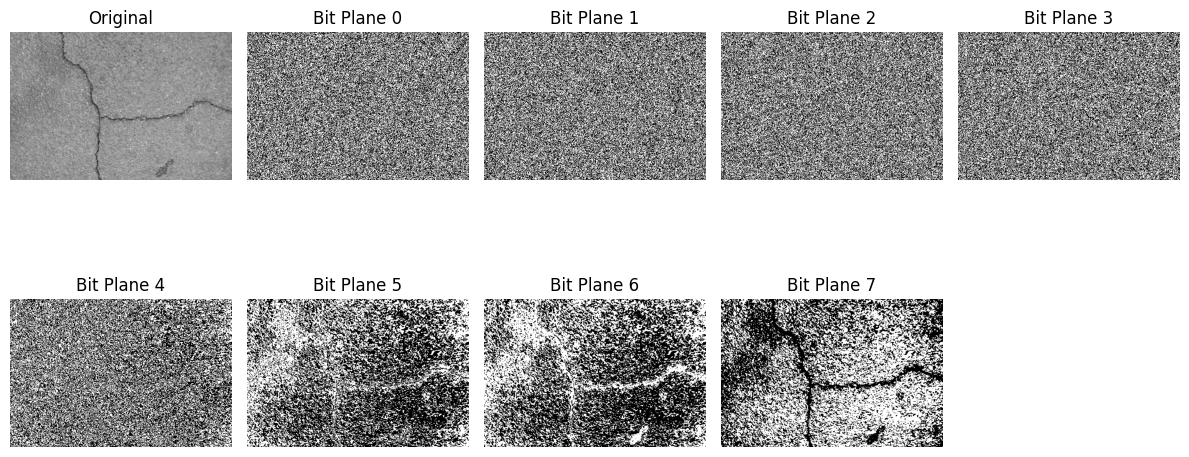

In [12]:
# Create bit planes
bit_planes = []
for i in range(8):
    # Extract bit-plane i
    bit_plane = (img >> i) & 1
    bit_planes.append(bit_plane)

# Visualization
plt.figure(figsize=(12, 6))

plt.subplot(2, 5, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

for i in range(8):
    plt.subplot(2, 5, i + 2)
    plt.imshow(bit_planes[i] * 255, cmap="gray")
    plt.title(f"Bit Plane {i}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("result/bit_planes.png")
plt.show()

# Inpainting with reflection

In [ ]:
def inpaint_with_reflection(
    original_img: np.ndarray,
    mask: np.ndarray,
    window_size=21,
    stride=5,
    priority="horizontal",
    gaussian_ksize=11,
    gaussian_sigma=1.0,
):
    if window_size % 2 == 0:
        raise Exception("Window size needs to be an odd number")
    if gaussian_ksize % 2 == 0:
        raise Exception("Gaussian kernel needs to be an odd number")

    img = original_img.copy().astype(np.uint8)
    h, w = img.shape[:2]

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR).astype(np.uint8)
        was_grayscale = True
        channels = 3
    else:
        was_grayscale = False
        channels = img.shape[2]

    mask_bool = mask > 127
    if mask_bool.ndim == 3:
        mask_bool = mask_bool.squeeze()

    original_mask_bool = mask_bool.copy()

    half_win = window_size // 2

    directions = (
        ["horizontal", "vertical"]
        if priority == "horizontal"
        else ["vertical", "horizontal"]
    )

    print("Inpainting bitplane...")
    result = np.zeros_like(img)
    for c in range(channels):
        channel = img[:, :, c]

        bit_planes = [(channel & (1 << b)) >> b for b in range(8)]

        processed_planes = []
        for bp in bit_planes:
            bp_processed = bp.copy()
            mask_processed = mask_bool.copy()

            for y in range(half_win, h - half_win, stride):
                for x in range(half_win, w - half_win, stride):
                    y1 = y - half_win
                    y2 = y + half_win + 1
                    x1 = x - half_win
                    x2 = x + half_win + 1

                    mask_window = mask_processed[y1:y2, x1:x2]

                    if not np.any(mask_window):
                        continue

                    for ry in range(window_size):
                        for rx in range(window_size):
                            if mask_window[ry, rx]:
                                py = y1 + ry
                                px = x1 + rx

                                for dir in directions:
                                    if dir == "horizontal":  # Horizontal reflection
                                        refl_rx = 2 * half_win - rx
                                        refl_ry = ry
                                    else:  # Vertical reflection
                                        refl_rx = rx
                                        refl_ry = 2 * half_win - ry

                                    # Absolute coordinate
                                    source_y = y1 + refl_ry
                                    source_x = x1 + refl_rx

                                    if 0 <= source_y < h and 0 <= source_x < w:
                                        if not mask_processed[source_y, source_x]:
                                            bp_processed[py, px] = bp[
                                                source_y, source_x
                                            ]
                                            mask_processed[py, px] = False
                                            break

            processed_planes.append(bp_processed)

        # Reconstruct
        reconstructed = np.zeros((h, w), dtype=np.uint8)
        for b in range(8):
            reconstructed |= processed_planes[b] << b

        result[:, :, c] = reconstructed

    # Gaussian smoothing
    if gaussian_ksize > 1:
        print(
            f"Gaussian blur (ksize={gaussian_ksize}, sigma={gaussian_sigma}) to crack regions..."
        )
        blurred = cv2.GaussianBlur(
            result, (gaussian_ksize, gaussian_ksize), gaussian_sigma
        )

        if channels == 1:
            crack_mask_3d = original_mask_bool
        else:
            crack_mask_3d = np.repeat(
                original_mask_bool[..., np.newaxis], channels, axis=2
            )

        result[crack_mask_3d] = blurred[crack_mask_3d]

    if was_grayscale:
        result = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    return result


# Inpainting with reflection and gradient

In [ ]:
def inpaint_with_gradient(
    original_img: np.ndarray,
    mask: np.ndarray,
    window_size=21,
    stride=5,
    priority="horizontal",
    gaussian_ksize=11,
    gaussian_sigma=1.0,
):
    if window_size % 2 == 0:
        raise Exception("Window size needs to be an odd number")
    if gaussian_ksize % 2 == 0:
        raise Exception("Gaussian kernel needs to be an odd number")

    img = original_img.copy().astype(np.uint8)
    h, w = img.shape[:2]

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR).astype(np.uint8)
        was_grayscale = True
        channels = 3
    else:
        was_grayscale = False
        channels = img.shape[2]

    mask_bool = mask > 127
    if mask_bool.ndim == 3:
        mask_bool = mask_bool.squeeze()

    original_mask_bool = mask_bool.copy()

    half_win = window_size // 2

    # Precompute gradient magnitude and angle on grayscale version
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if channels == 3 else img.squeeze()
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.hypot(sobelx, sobely)
    grad_ang = np.arctan2(sobely, sobelx)  # -pi to pi

    result = np.zeros_like(img)

    for c in range(channels):
        channel = img[:, :, c]
        bit_planes = [(channel & (1 << b)) >> b for b in range(8)]

        processed_planes = []
        for bp in bit_planes:
            bp_processed = bp.copy()
            mask_processed = mask_bool.copy()

            for y in range(half_win, h - half_win, stride):
                for x in range(half_win, w - half_win, stride):
                    y1 = y - half_win
                    y2 = y + half_win + 1
                    x1 = x - half_win
                    x2 = x + half_win + 1

                    mask_window = mask_processed[y1:y2, x1:x2]
                    if not np.any(mask_window):
                        continue

                    # Local gradient
                    local_ang = grad_ang[y1:y2, x1:x2]
                    local_mag = grad_mag[y1:y2, x1:x2]

                    # Weighted average angle
                    angles = local_ang.flatten()
                    weights = local_mag.flatten()
                    if np.sum(weights) > 0:
                        mean_angle = np.arctan2(
                            np.sum(weights * np.sin(angles)),
                            np.sum(weights * np.cos(angles)),
                        )
                    else:
                        mean_angle = 0

                    if abs(np.cos(mean_angle)) > abs(np.sin(mean_angle)):
                        # Dominant horizontal gradient → vertical crack → horizontal reflection
                        directions = ["horizontal", "vertical"]
                    elif (np.cos(mean_angle)) < abs(np.sin(mean_angle)):
                        # Dominant vertical gradient → horizontal crack → vertical reflection
                        directions = ["vertical", "horizontal"]
                    else:
                        if priority == "horizontal":
                            directions = ["horizontal", "vertical"]
                        else:
                            directions = ["vertical", "horizontal"]

                    for ry in range(window_size):
                        for rx in range(window_size):
                            if not mask_window[ry, rx]:
                                continue

                            py = y1 + ry
                            px = x1 + rx

                            filled = False
                            for dir in directions:
                                if dir == "horizontal":
                                    refl_rx = 2 * half_win - rx
                                    refl_ry = ry
                                else:
                                    refl_rx = rx
                                    refl_ry = 2 * half_win - ry

                                source_y = y1 + refl_ry
                                source_x = x1 + refl_rx

                                if 0 <= source_y < h and 0 <= source_x < w:
                                    if not mask_processed[source_y, source_x]:
                                        bp_processed[py, px] = bp[
                                            source_y, source_x
                                        ]
                                        mask_processed[py, px] = False
                                        filled = True
                                        break

            processed_planes.append(bp_processed)

        # Reconstruct
        reconstructed = np.zeros((h, w), dtype=np.uint8)
        for b in range(8):
            reconstructed |= processed_planes[b] << b

        result[:, :, c] = reconstructed

    # Gaussian smoothing
    if gaussian_ksize > 1:
        print(f"Gaussian blur (ksize={gaussian_ksize}, sigma={gaussian_sigma})...")
        blurred = cv2.GaussianBlur(
            result, (gaussian_ksize, gaussian_ksize), gaussian_sigma
        )

        crack_mask_3d = (
            original_mask_bool[..., np.newaxis]
            if channels > 1
            else original_mask_bool
        )
        if channels > 1:
            crack_mask_3d = np.repeat(crack_mask_3d, channels, axis=2)

        result[crack_mask_3d] = blurred[crack_mask_3d]

    if was_grayscale:
        result = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    return result
